In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.describe()
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

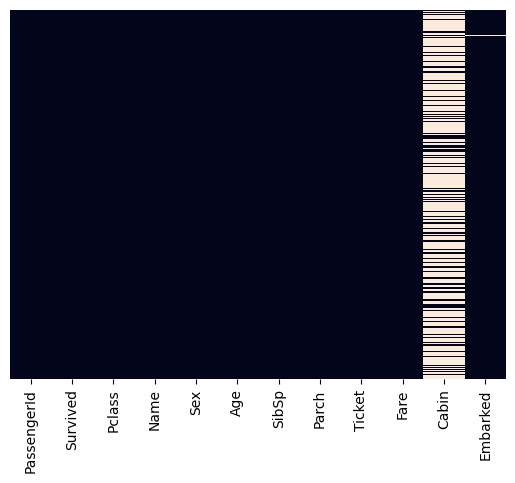

In [10]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.show()

In [9]:
df = pd.read_csv(url)
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [ ]:
df['Embarked'] = df['Embarked'].fillna(...)
df['Embarked'] = df['Embarked'].fillna(...)

In [ ]:

df.drop('Cabin', axis=1, inplace=True)

In [ ]:
df.select_dtypes(include=['object', 'string']).columns

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='str')

In [ ]:
# Convert Sex column into numeric values
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [ ]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [ ]:
num_cols = ['Age', 'Fare']


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


In [25]:
df[['Age','Fare']].head()


,Age,Fare
0,-0.530377,-0.502445
1,0.571831,0.786845
2,-0.254825,-0.488854
3,0.365167,0.420730
4,0.365167,-0.486337


<Axes: xlabel='Fare'>

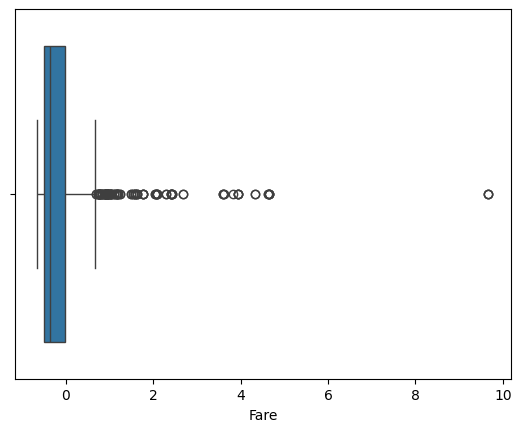

In [26]:
sns.boxplot (x=df['Fare'])

In [21]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR =  Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [23]:
outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]
print(len(outliers))


116


In [26]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True, errors='ignore')

In [27]:
X = df.drop('Survived', axis=1)
y = df['Survived']


In [28]:
print(X.shape)
print(y.shape)


(891, 9)
(891,)
